In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [4]:
# load training data
X_train = np.load(r"D:\SER_Cross\features\train\X.npy")
y_train = np.load(r"D:\SER_Cross\features\train\y.npy")

# load validation data
X_val = np.load(r"D:\SER_Cross\features\val\X.npy")
y_val = np.load(r"D:\SER_Cross\features\val\y.npy")

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (5068, 128, 300)
Validation shape: (1031, 128, 300)


In [5]:
X_train = np.transpose(X_train,(0,2,1))
X_val = np.transpose(X_val,(0,2,1))

print("Fixed train shape:",X_train.shape)

Fixed train shape: (5068, 300, 128)


In [6]:
input_shape = (300,128)

model = models.Sequential()

# CNN feature extractor
model.add(layers.Conv1D(64,3,activation='relu',input_shape=input_shape))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling1D(2))
model.add(layers.Dropout(0.3))

model.add(layers.Conv1D(128,3,activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling1D(2))
model.add(layers.Dropout(0.3))

model.add(layers.Conv1D(256,3,activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling1D(2))

# temporal modelling
model.add(layers.Bidirectional(layers.LSTM(128,return_sequences=True)))
model.add(layers.Dropout(0.4))

model.add(layers.Bidirectional(layers.LSTM(64)))

# classifier
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.4))
model.add(layers.Dense(3,activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 298, 64)           24640     
                                                                 
 batch_normalization (Batch  (None, 298, 64)           256       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 149, 64)           0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 149, 64)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 147, 128)          24704     
                                                                 
 batch_normalization_1 (Bat  (None, 147, 128)          5

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-6
)

In [9]:
# keep only 3 emotions
mask_train = np.isin(y_train,[0,1,2])
mask_val = np.isin(y_val,[0,1,2])

X_train = X_train[mask_train]
y_train = y_train[mask_train]

X_val = X_val[mask_val]
y_val = y_val[mask_val]

print("Train samples:",len(y_train))
print("Validation samples:",len(y_val))
print("Labels:",np.unique(y_train))

Train samples: 3012
Validation samples: 617
Labels: [0 1 2]


In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop,lr_reduce]
)

Epoch 1/60
95/95 [==============================] - 15s 105ms/step - loss: 0.9166 - accuracy: 0.5710 - val_loss: 1.2092 - val_accuracy: 0.3955 - lr: 3.0000e-04
Epoch 2/60
95/95 [==============================] - 9s 90ms/step - loss: 0.8126 - accuracy: 0.6328 - val_loss: 0.9678 - val_accuracy: 0.5478 - lr: 3.0000e-04
Epoch 3/60
95/95 [==============================] - 9s 91ms/step - loss: 0.7833 - accuracy: 0.6604 - val_loss: 0.8598 - val_accuracy: 0.6110 - lr: 3.0000e-04
Epoch 4/60
95/95 [==============================] - 9s 90ms/step - loss: 0.7676 - accuracy: 0.6541 - val_loss: 0.8794 - val_accuracy: 0.6110 - lr: 3.0000e-04
Epoch 5/60
95/95 [==============================] - 9s 90ms/step - loss: 0.7436 - accuracy: 0.6760 - val_loss: 0.9418 - val_accuracy: 0.5867 - lr: 3.0000e-04
Epoch 6/60
95/95 [==============================] - 8s 88ms/step - loss: 0.7203 - accuracy: 0.6843 - val_loss: 1.0682 - val_accuracy: 0.5089 - lr: 3.0000e-04
Epoch 7/60
95/95 [==============================] 

In [11]:
model.save(r"D:\SER_Cross\models\crnn_3emotion_final.h5")
print("Model saved successfully")

Model saved successfully


c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [12]:
loss,acc = model.evaluate(X_val,y_val)

print("Validation Accuracy:",acc)

20/20 [==============================] - 1s 27ms/step - loss: 0.8598 - accuracy: 0.6110
Validation Accuracy: 0.6110210418701172


In [22]:
val_loss, val_acc = model.evaluate(X_val, y_val)

print("====================================")
print("FINAL VALIDATION ACCURACY:", round(val_acc * 100, 2), "%")
print("FINAL VALIDATION LOSS:", round(val_loss, 4))
print("====================================")

20/20 [==============================] - 0s 19ms/step - loss: 0.8598 - accuracy: 0.6110
FINAL VALIDATION ACCURACY: 61.1 %
FINAL VALIDATION LOSS: 0.8598


20/20 [==============================] - 1s 24ms/step


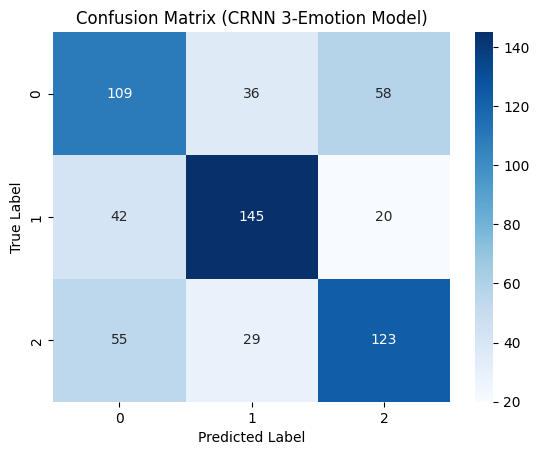

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Predictions
y_pred = model.predict(X_val)

# Step 2: Convert predictions
y_pred_classes = np.argmax(y_pred, axis=1)

# Step 3: TRUE labels (NO argmax here)
y_true = y_val

# Step 4: Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix (CRNN 3-Emotion Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.savefig("confusion_matrix_final.png", dpi=300)
plt.show()

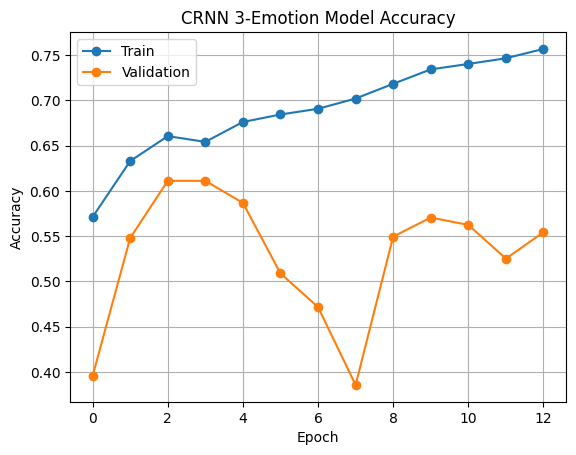

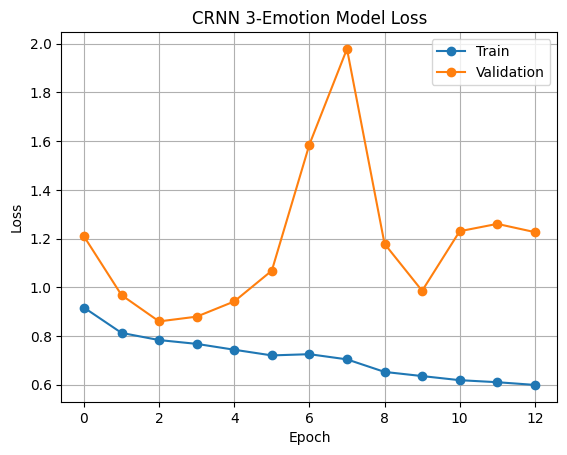

In [17]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title('CRNN 3-Emotion Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()

plt.savefig("final_accuracy.png")  # Save for IEEE
plt.show()


# Loss Graph
plt.figure()
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')
plt.title('CRNN 3-Emotion Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.grid()

plt.savefig("final_loss.png")  # Save for IEEE
plt.show()